# Graph Signal Processing of Brain Connectivity Data
This notebook implements the workflow for analyzing structural and functional brain networks using graph signal processing.

In [47]:
# ============================
# Clone entire Github repository
# ============================

!git clone https://github.com/gpreti/EE-629.git

print("Repository cloned.") #everything exist locally now, path: "EE-629/"

Cloning into 'EE-629'...
remote: Enumerating objects: 317, done.
remote: Counting objects: 100% (115/115), done.
remote: Compressing objects: 100% (106/106), done.
remote: Total 317 (delta 30), reused 1 (delta 1), pack-reused 202 (from 1)
Receiving objects: 100% (317/317), 96.42 MiB | 30.77 MiB/s, done.
Resolving deltas: 100% (78/78), done.
Updating files: 100% (50/50), done.
Repository cloned.


In [42]:
##### to pull when adding new files into github
%cd /content/EE-629
!git pull

/content/EE-629
Already up to date.


In [48]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from numpy.linalg import norm, eig
from scipy.stats import zscore

path_exercise='EE-629/EX4/'

# Load data: structural connectome and functional timecourses (I can find it in the data folders of previous excercises)
A = scipy.io.loadmat(path_exercise+'DATA/SC.mat')['SC']
X = scipy.io.loadmat(path_exercise+'DATA/X.mat')['X']



Text(0, 0.5, 'regions')

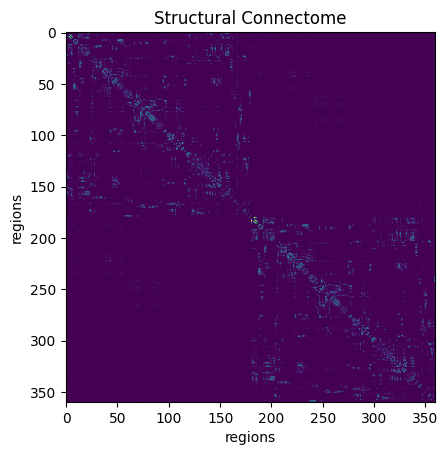

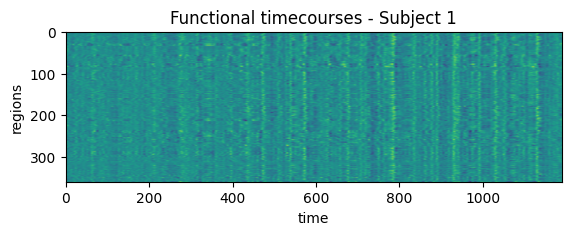

In [49]:
# Visualize data
plt.figure(); plt.imshow(np.log1p(A)); plt.title('Structural Connectome'); plt.xlabel('regions'); plt.ylabel('regions')
plt.figure(); plt.imshow(X[:, :, 0]); plt.title('Functional timecourses - Subject 1'); plt.xlabel('time'); plt.ylabel('regions')


Text(0, 0.5, 'regions')

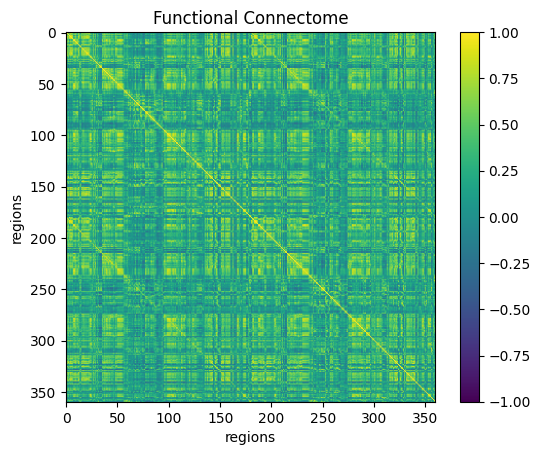

In [50]:
# Compute functional connectivity
FC = np.corrcoef(X[:, :, 0])
plt.figure(); plt.imshow(FC, vmin=-1, vmax=1); plt.colorbar(); plt.title('Functional Connectome'); plt.xlabel('regions'); plt.ylabel('regions')


Text(0, 0.5, 'regions')

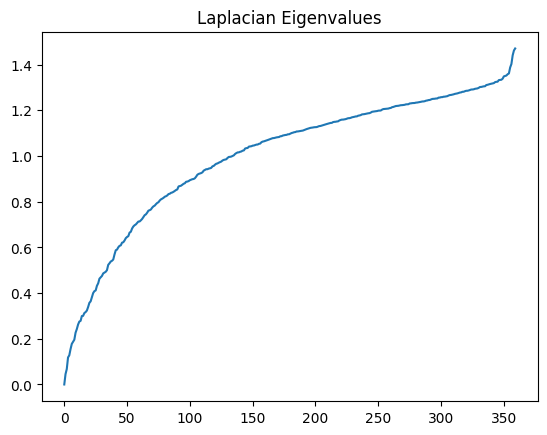

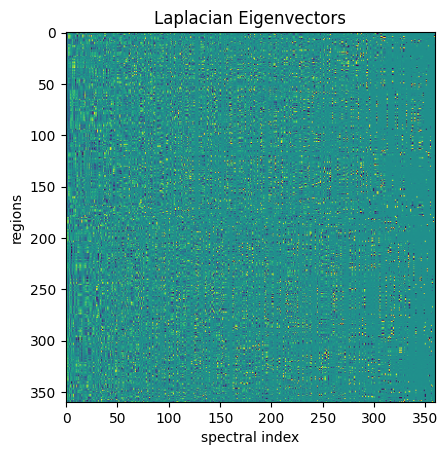

In [51]:
# Normalize adjacency matrix
D = np.diag(np.sum(A, axis=1))
D_inv_sqrt = np.diag(1.0 / np.sqrt(np.sum(A, axis=1)))
Anorm = D_inv_sqrt @ A @ D_inv_sqrt

# Laplacian
Lnorm = np.eye(A.shape[0]) - Anorm
LambdaL, U = eig(Lnorm)
LambdaL = np.real(LambdaL)
U = np.real(U)

# Sort eigenvalues and eigenvectors
idx = np.argsort(LambdaL)
LambdaL = LambdaL[idx]
U = U[:, idx]

plt.figure(); plt.plot(LambdaL); plt.title('Laplacian Eigenvalues')
plt.figure(); plt.imshow(U, vmin=-0.2, vmax=0.2); plt.title('Laplacian Eigenvectors'); plt.xlabel('spectral index'); plt.ylabel('regions')


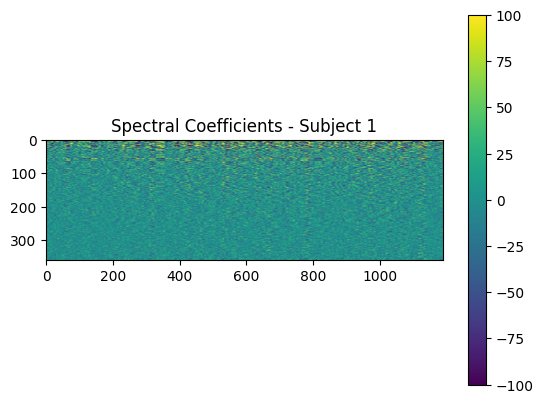

In [53]:
# Graph Fourier Transform
nsubjs = X.shape[2]
X_hat = np.array([U.T @ X[:, :, s] for s in range(nsubjs)]).transpose(1, 2, 0)

plt.figure(); plt.imshow(X_hat[:, :, 0],vmin=-100, vmax=100); plt.title('Spectral Coefficients - Subject 1'); plt.colorbar()


In [54]:
X_hat.shape

(360, 1190, 5)

Text(0.5, 1.0, 'High-Frequency Harmonics')

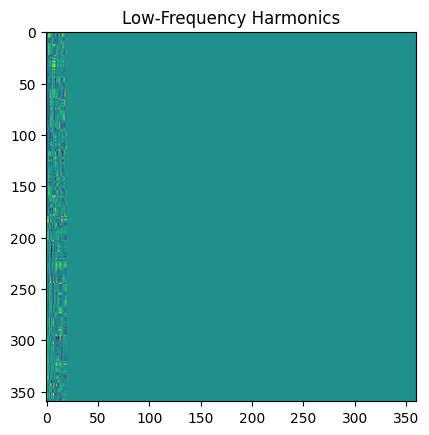

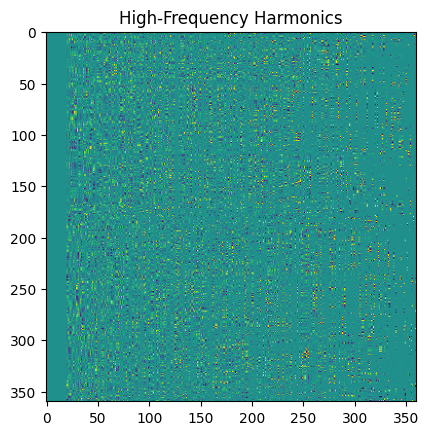

In [55]:
#choose cutoff frequency
NN=20


# Low- and high-frequency eigenvectors
Ulow = np.zeros_like(U)
Uhigh = np.zeros_like(U)
Ulow[:, :NN] = U[:, :NN]
Uhigh[:, NN:] = U[:, NN:]

plt.figure(); plt.imshow(Ulow, vmin=-0.2, vmax=0.2); plt.title('Low-Frequency Harmonics')
plt.figure(); plt.imshow(Uhigh, vmin=-0.2, vmax=0.2); plt.title('High-Frequency Harmonics')


In [29]:
print(nsubjs)

5


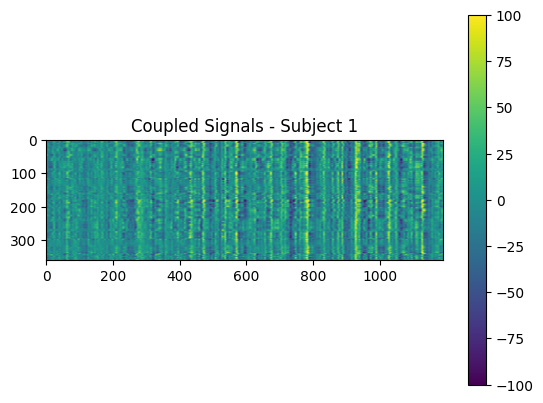

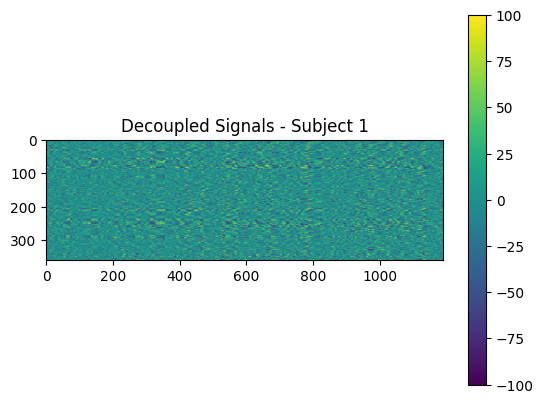

In [57]:
# Reconstruct signals
X_c = np.array([Ulow @ X_hat[:, :, s] for s in range(nsubjs)]).transpose(1, 2, 0)
X_d = np.array([Uhigh @ X_hat[:, :, s] for s in range(nsubjs)]).transpose(1, 2, 0)

plt.figure(); plt.imshow(X_c[:, :, 0],vmin=-100, vmax=100); plt.title('Coupled Signals - Subject 1');plt.colorbar()
plt.figure(); plt.imshow(X_d[:, :, 0],vmin=-100, vmax=100); plt.title('Decoupled Signals - Subject 1');plt.colorbar()


Text(0.5, 0, 'regions')

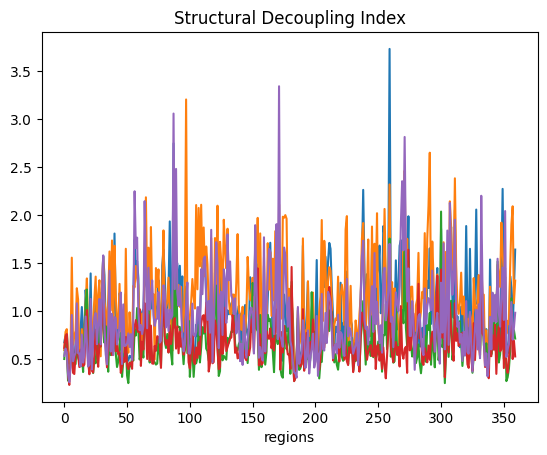

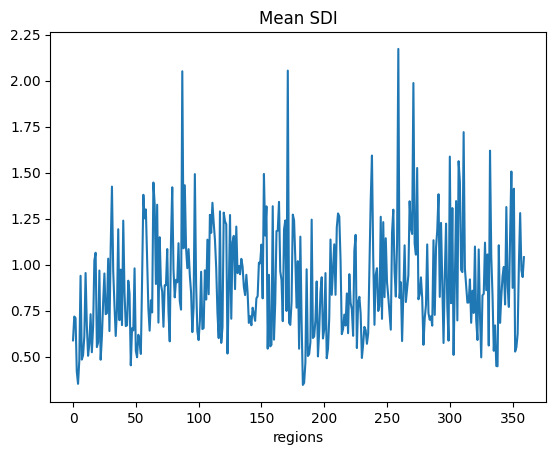

In [58]:
# Norms and Structural Decoupling Index (SDI)
N_c = np.linalg.norm(X_c, axis=1)
N_d = np.linalg.norm(X_d, axis=1)
SDI = N_d / (N_c + 1e-8)
meanSDI = np.mean(SDI, axis=1)

plt.figure(); plt.plot(SDI); plt.title('Structural Decoupling Index'); plt.xlabel('regions')
plt.figure(); plt.plot(meanSDI); plt.title('Mean SDI'); plt.xlabel('regions')


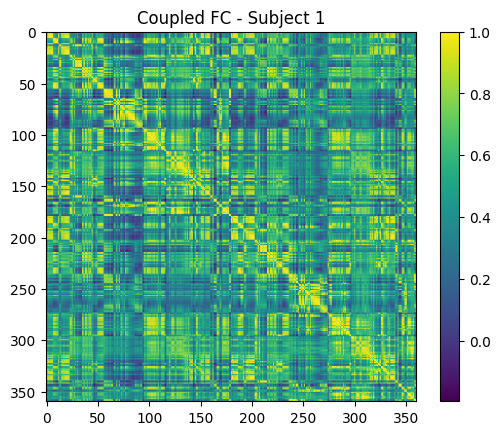

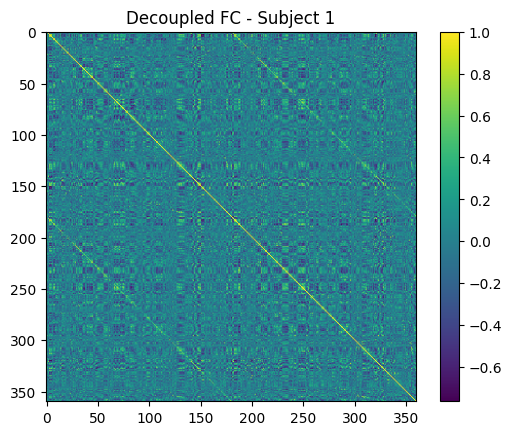

In [59]:
# Compute coupled and decoupled FC
FC_c = np.array([np.corrcoef(X_c[:, :, s]) for s in range(nsubjs)])
FC_d = np.array([np.corrcoef(X_d[:, :, s]) for s in range(nsubjs)])

plt.figure(); plt.imshow(FC_c[0]); plt.title('Coupled FC - Subject 1'); plt.colorbar()
plt.figure(); plt.imshow(FC_d[0]); plt.title('Decoupled FC - Subject 1'); plt.colorbar()
